# Project 8: Forward Volatility from the SOFR Cap Market

**Data**: `project_cap_vol_ts.xlsx`, `cap_curves_2025-06-30.xlsx`, `ref_rates.xlsx`

## Project Statement

Strip forward volatilities from the SOFR cap market over 2022–2025 and test whether the forward vol curve predicts future spot vol—a Fama–Bliss analog for the volatility term structure. Characterize the resulting volatility term premium and analyze how it varies across the hiking, pause, and easing regimes of the Fed's policy cycle.

## Context

### From Flat Vol to Forward Vol

In the cap market, prices are quoted in **flat volatility**—a single implied vol that prices all caplets in a given cap, regardless of their individual maturities. This is a quoting convention, analogous to yield-to-maturity for bonds. Just as bond pricing requires spot rates (not YTM), derivative pricing requires **forward volatilities** that assign each caplet its own vol consistent with its maturity.

Extracting forward vols from flat vols is a **bootstrap** problem: given a sequence of cap prices at maturities $T_1 < T_2 < \ldots$, strip out the incremental caplet prices and invert Black's formula to recover the forward vol at each tenor. Exercise 7.1 walks through this on a single date.

### The Vol Curve as a Forecast

The forward vol curve has a natural interpretation as a forecast of future rate volatility. The $\tau$-year forward caplet vol represents the market's expectation (plus any risk premium) for rate volatility during the quarter ending at $\tau$.

A natural question, then, is whether forward vol is an unbiased predictor of future spot vol. This is the **Fama–Bliss analog for volatility**: just as forward rates predict future spot rates (but with a term premium), forward vols may predict future spot vols—but with a **volatility term premium**.

### Normal vs Black Vol

Bloomberg quotes cap vols in **normal** (Bachelier) terms, reported in basis points. For comparing forward vol across different rate levels and to realized rate volatility, normal vol is the appropriate measure:

$$\sigma_{\text{normal}} \approx \sigma_{\text{Black}} \times f$$

where $f$ is the forward rate. This approximation is exact at-the-money.

### The 2022–2025 Rate Cycle

This project covers a period of extraordinary rate volatility:

| Period | Regime | SOFR Range | Implication |
|--------|--------|------------|-------------|
| Mar 2022 – Jul 2023 | Aggressive hiking | 0.05% → 5.30% | High realized vol, uncertain terminal rate |
| Aug 2023 – Aug 2024 | Pause | ~5.30% | Low realized vol, high implied vol (when does the cut come?) |
| Sep 2024 – Dec 2025 | Easing | 5.30% → ~3.75% | Moderate realized vol, declining implied vol |

These three regimes create a natural laboratory for studying how the volatility term premium behaves under different policy conditions.

## Resources

### Course Materials

- **Discussion 7.1**: Forward Volatility and Caps — flat vs forward vol, stripping mechanics, Black's formula for caplets
- **Exercise 7.1**: Stripping Caps — single-date bootstrap of forward vols from flat vols (the starting point for Q1)
- **Discussion 5.1**: SOFR Swap Curve — discount factor construction needed for cap pricing

### External Reading

- CME Group: [Interest Rate Volatility](https://www.cmegroup.com/education/courses/introduction-to-interest-rate-options.html) — market structure for rate options
- NY Fed: [SOFR](https://www.newyorkfed.org/markets/reference-rates/sofr) — rate calculation methodology
- Federal Reserve: [FOMC Calendars](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm) — policy dates for regime classification

### Data Files

| File | Description | Frequency | Date Range |
|------|-------------|-----------|------------|
| `project_cap_vol_ts.xlsx` | Cap flat vols (normal, bp) + SOFR swap rates | Daily | 2022–2025 |
| `cap_curves_2025-06-30.xlsx` | Processed rate/vol curves for validation | Single date | 2025-06-30 |
| `ref_rates.xlsx` | Daily SOFR, Fed Funds, T-bill rates | Daily | 2018–2025 |

**Data location**: All files are in the `./data/` directory relative to this notebook.

#### Cap Vol Data Details

The `project_cap_vol_ts.xlsx` file contains two sheets:
- **`cap`**: ATM normal vol quotes for 1Y–10Y SOFR caps (Bloomberg `USCNSQ{1-10} SMKO Curncy`). Vols are in basis points.
- **`sofr`**: SOFR swap rates at monthly/quarterly/annual tenors up to 10Y. Rates are in percent, annually compounded.

The first row of each sheet contains maturity metadata (in years). Subsequent rows are daily observations.

### Additional Data Sources
- **FRED**: Daily SOFR rate for realized vol computation (already in `ref_rates.xlsx`)
- **Bloomberg** (optional): If you have access, you can pull additional cap maturities or OTM strikes via the `VCUB` screen

## Data Preview

The following code loads the data and creates initial visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import PchipInterpolator
import statsmodels.api as sm

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('./data')

In [2]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest quarter (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

print(f'Cap data: {cap_data.shape[0]} days, maturities: {list(cap_data.columns)}')
print(f'Date range: {cap_data.index.min().date()} to {cap_data.index.max().date()}')
cap_data.tail(3)

Cap data: 989 days, maturities: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Date range: 2022-03-17 to 2025-12-31


maturity,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
date,,,,,,,,,,
2025-12-29,52.2,66.8,73.5,77.3,79.6,81.2,82.1,82.8,83.3,83.7
2025-12-30,50.9,66.1,72.9,76.7,78.9,80.4,81.3,81.9,82.4,82.8
2025-12-31,50.8,65.9,72.9,76.7,78.9,80.4,81.4,82.0,NaN,NaN


In [3]:
# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

print(f'SOFR swap data: {sofr_data.shape[0]} days, {sofr_data.shape[1]} tenors')
sofr_data.tail(3)

SOFR swap data: 1033 days, 21 tenors


maturity,0.25,0.50,0.75,1.00,1.25,1.50,1.75,...,4.50,5.00,6.00,7.00,8.00,9.00,10.00
date,,,,,,,,,,,,,,,
2025-12-29,0.036670,0.035886,0.034989,0.034239,0.033538,0.033140,0.032940,...,0.033746,0.034104,0.034800,0.035506,0.036177,0.036827,0.037457
2025-12-30,0.036567,0.035805,0.034931,0.034190,0.033510,0.033115,0.032919,...,0.033849,0.034214,0.034927,0.035648,0.036330,0.036989,0.037621
2025-12-31,0.036517,0.035796,0.034961,0.034270,0.033631,0.033285,0.033140,...,0.034226,0.034638,0.035355,0.036068,0.036735,0.037388,0.038023


In [4]:
# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100
print(f'SOFR daily: {len(sofr_daily)} observations, {sofr_daily.index.min().date()} to {sofr_daily.index.max().date()}')

SOFR daily: 1935 observations, 2018-04-03 to 2025-12-31


In [5]:
# Load validation curves (single-date, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')

print(f'Validation curves: {curves_validation.shape}')
display(curves_validation.head())

Validation curves: (40, 6)


,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
tenor,,,,,,
0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341


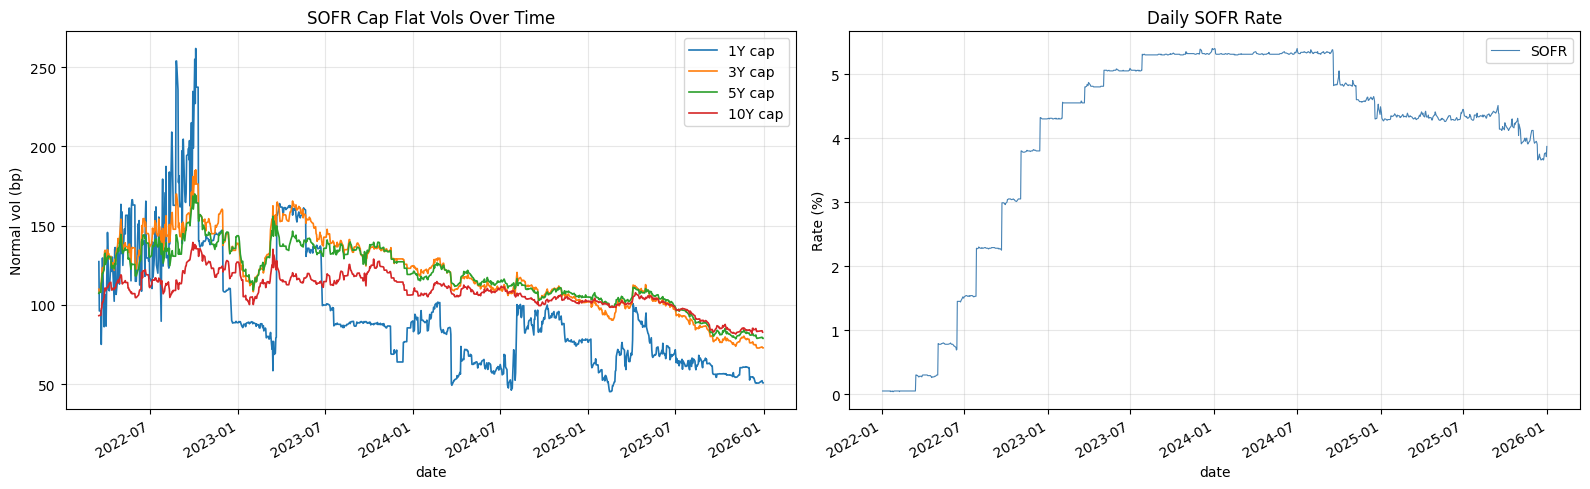

In [6]:
# Figure 1: Cap flat vols over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for mat in [1.0, 3.0, 5.0, 10.0]:
    if mat in cap_data.columns:
        cap_data[mat].dropna().plot(ax=ax, label=f'{int(mat)}Y cap', linewidth=1.2)
ax.set_ylabel('Normal vol (bp)')
ax.set_title('SOFR Cap Flat Vols Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# SOFR rate for context
ax = axes[1]
sofr_rate_pct = sofr_daily.loc['2022':] * 100
sofr_rate_pct.plot(ax=ax, linewidth=0.8, color='steelblue', label='SOFR')
ax.set_ylabel('Rate (%)')
ax.set_title('Daily SOFR Rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

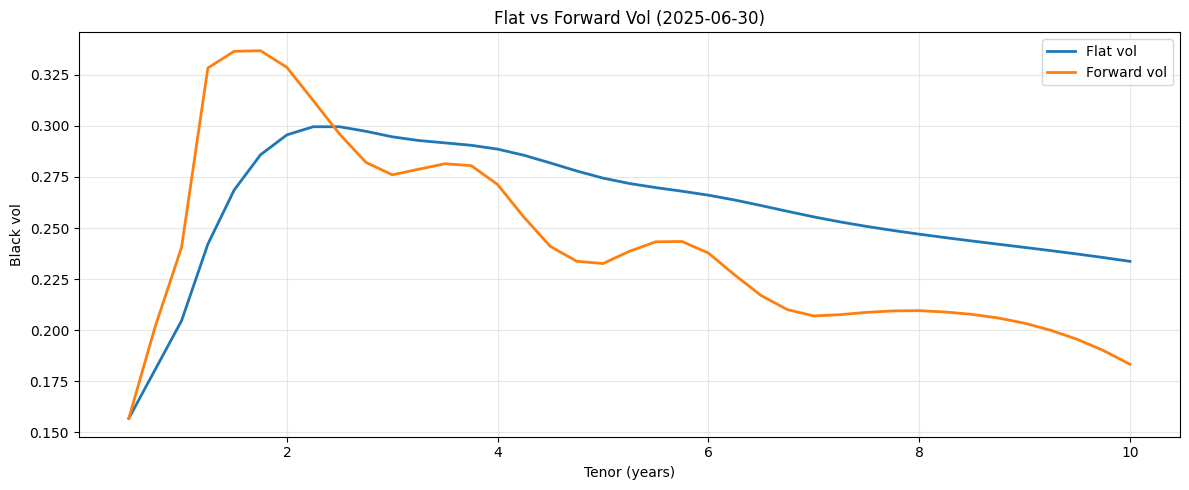

In [7]:
# Figure 2: Flat vs forward vol on the validation date
fig, ax = plt.subplots()
curves_validation['flat vols'].dropna().plot(ax=ax, label='Flat vol', linewidth=2)
curves_validation['fwd vols'].dropna().plot(ax=ax, label='Forward vol', linewidth=2)
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Black vol')
ax.set_title('Flat vs Forward Vol (2025-06-30)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key Formulas

Refer to **Discussion 7.1** and **Exercise 7.1** for detailed derivations.

### Black's Formula for a Caplet

$$P_{\text{caplet}} = \frac{100}{4} \cdot Z_\tau \left[ f_\tau \mathcal{N}(d_1) - K \mathcal{N}(d_2) \right]$$

where $d_1 = \frac{\ln(f_\tau/K) + \frac{\sigma^2}{2}(\tau - 0.25)}{\sigma\sqrt{\tau - 0.25}}$ and $d_2 = d_1 - \sigma\sqrt{\tau - 0.25}$.

### Cap Price from Flat Vol

A cap with maturity $T$ and flat vol $\sigma_{\text{flat},T}$:

$$P_{\text{cap}}(T) = \sum_{\tau=0.5}^{T} P_{\text{caplet}}(\tau, \sigma_{\text{flat},T}, K=s_T)$$

where $s_T$ is the ATM swap rate.

### Forward Vol Bootstrap

The caplet price at $\tau$ is:
$$P_{\text{caplet}}(\tau) = P_{\text{cap}}(\tau) - P_{\text{cap}}(\tau - 0.25)$$

Invert Black's formula to find $\sigma_{\text{fwd},\tau}$.

### Normal Vol Conversion (ATM)

$$\sigma_{\text{normal}} = \sigma_{\text{Black}} \times f$$

### Fama–Bliss Analog for Volatility

$$\sigma_{\text{spot}}(t{+}h, \delta) = \alpha + \beta \cdot \sigma_{\text{fwd}}(t, \tau) + \varepsilon_t$$

where $h = \tau - \delta$ is the forecast horizon and $\delta$ is the spot caplet tenor.

### Volatility Term Premium

$$\text{VTP}_t(\tau) = \sigma_{\text{fwd}}(t, \tau) - \sigma_{\text{spot}}(t{+}h, \delta)$$

### Realized Vol

$$\sigma_{\text{realized}, t \to t+k} = \text{std}(\Delta r_{\text{SOFR}}) \times \sqrt{252}$$

computed over daily SOFR rate changes in the window $[t, t+k]$.

## Questions

Address the following questions in your analysis.

### Helper Functions

In [8]:
def get_market_slices(date, cap_data, sofr_data):
    """Extract one-date cap and swap slices."""
    cap_slice = cap_data.loc[date].dropna().astype(float)
    swap_slice = sofr_data.loc[date].dropna().astype(float)
    return cap_slice, swap_slice

In [9]:
def build_flat_vol_curve(cap_slice, swap_slice, quarterly_grid):
    """
    Convert annual cap normal vols (bp) to Black flat vols,
    then PCHIP-interpolate to the quarterly tenor grid.

    PCHIP preserves monotonicity between knots and avoids the
    sawtooth artifacts that linear interpolation introduces in
    the forward vol bootstrap.

    Sub-1Y tenors: set equal to the observed 1Y flat vol, since
    the 1Y cap is the shortest observed instrument and its flat
    vol applies uniformly to all its constituent caplets.
    """
    normal_vol = cap_slice / 10000.0

    # Swap rates at cap maturities (for normal -> Black conversion)
    approx_atm_rates = (
        swap_slice.reindex(normal_vol.index)
        .interpolate(method="linear", limit_direction="both")
    )

    black_vol = normal_vol / approx_atm_rates

    # PCHIP interpolation of Black flat vols onto quarterly grid (1Y+ only)
    known_tenors = black_vol.dropna().index.values.astype(float)
    known_vols = black_vol.dropna().values

    grid_float = np.array(quarterly_grid, dtype=float)

    # Only PCHIP-interpolate within the observed range (1Y to 10Y)
    min_obs = known_tenors.min()  # typically 1.0
    pchip = PchipInterpolator(known_tenors, known_vols)

    flat_vols = pd.Series(index=quarterly_grid, dtype=float)

    for t in grid_float:
        if t >= min_obs:
            flat_vols.loc[t] = float(pchip(t))
        elif t >= 0.5:
            # Sub-1Y tenors: use the 1Y flat vol (shortest observed cap)
            flat_vols.loc[t] = known_vols[0]
        else:
            flat_vols.loc[t] = np.nan

    flat_vols.name = "flat vols"

    # First caplet (0.25Y) has no vol — it settles immediately
    flat_vols.loc[0.25] = np.nan
    return flat_vols

In [10]:
def build_quarterly_swap_curve(swap_slice, quarterly_grid):
    """Interpolate swap rates onto the quarterly tenor grid."""
    swap_q = (
        swap_slice.reindex(quarterly_grid)
        .interpolate(method="linear", limit_direction="both")
    )
    swap_q.name = "swap rates"
    return swap_q

In [11]:
def bootstrap_discount_forward_curve(swap_q, delta):
    """
    Vanilla par-swap bootstrap:
      swap rates -> discounts -> spot rates -> forward rates
    """
    tenor_grid = np.array(swap_q.index, dtype=float)

    discounts = pd.Series(index=swap_q.index, dtype=float)

    for j, T in enumerate(tenor_grid, start=1):
        S = swap_q.loc[T]
        if j == 1:
            discounts.loc[T] = 1 / (1 + S * delta)
        else:
            prev_times = tenor_grid[:j-1]
            discounts.loc[T] = (1 - S * delta * discounts.loc[prev_times].sum()) / (1 + S * delta)

    discounts.name = "discounts"

    spot_rates = pd.Series(index=swap_q.index, dtype=float)
    for T in tenor_grid:
        spot_rates.loc[T] = discounts.loc[T] ** (-1 / T) - 1
    spot_rates.name = "spot rates"

    forwards = pd.Series(index=swap_q.index, dtype=float)
    forwards.loc[tenor_grid[0]] = np.nan

    for j in range(1, len(tenor_grid)):
        T_prev = tenor_grid[j-1]
        T = tenor_grid[j]
        forwards.loc[T] = (discounts.loc[T_prev] / discounts.loc[T] - 1) / delta

    forwards.name = "forwards"
    return discounts, spot_rates, forwards

In [12]:
def black_caplet_price(F, K, sigma, tau, DF, delta, notional):
    """Price a single caplet using Black's formula."""
    if pd.isna(F) or pd.isna(K) or pd.isna(sigma) or pd.isna(DF):
        return np.nan

    option_expiry = tau - delta
    if option_expiry <= 0:
        return np.nan

    if sigma <= 0:
        return notional * delta * DF * max(F - K, 0.0)

    vol_sqrt_t = sigma * np.sqrt(option_expiry)
    if vol_sqrt_t <= 0:
        return notional * delta * DF * max(F - K, 0.0)

    d1 = (np.log(F / K) + 0.5 * sigma**2 * option_expiry) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t

    return notional * delta * DF * (F * norm.cdf(d1) - K * norm.cdf(d2))


def implied_black_caplet_vol(price, F, K, tau, DF, delta, notional):
    """Invert Black's formula to find implied caplet vol via Brent's method."""
    if pd.isna(price) or pd.isna(F) or pd.isna(K) or pd.isna(tau) or pd.isna(DF):
        return np.nan

    option_expiry = tau - delta
    if option_expiry <= 0:
        return np.nan

    intrinsic = notional * delta * DF * max(F - K, 0.0)

    # No time value => no meaningful implied vol
    if price <= intrinsic + 1e-12:
        return np.nan

    def objective(sigma):
        return black_caplet_price(F, K, sigma, tau, DF, delta=delta, notional=notional) - price

    try:
        return brentq(objective, 1e-8, 5.0)
    except ValueError:
        return np.nan

In [13]:
def price_caps_from_flat_vols(flat_vols, swap_q, discounts, forwards, delta, notional):
    """
    Price each T-maturity cap using:
      - flat vol sigma_flat(T)
      - ATM strike K = swap rate at T
      - sum of Black caplets from 0.5 to T
    """
    tenor_grid = np.array(flat_vols.index, dtype=float)
    cap_prices = pd.Series(index=flat_vols.index, dtype=float)

    for T in tenor_grid:
        sigma_flat = flat_vols.loc[T]

        if T < 0.50 or pd.isna(sigma_flat):
            cap_prices.loc[T] = np.nan
            continue

        K = swap_q.loc[T]
        cap_val = 0.0

        caplet_payment_dates = tenor_grid[(tenor_grid >= 0.50) & (tenor_grid <= T)]

        for tau in caplet_payment_dates:
            F = forwards.loc[tau]
            DF = discounts.loc[tau]
            cap_val += black_caplet_price(F=F, K=K, sigma=sigma_flat, tau=tau, DF=DF, delta=delta, notional=notional)

        cap_prices.loc[T] = cap_val

    cap_prices.name = "cap prices"
    return cap_prices

In [14]:
def strip_caplet_prices(cap_prices, delta):
    """
    Strip caplet prices from adjacent cap prices:
      caplet(T) = cap(T) - cap(T - delta)
    Floors at zero to prevent no-arbitrage violations from interpolation noise.
    """
    tenor_grid = np.array(cap_prices.index, dtype=float)
    caplet_prices = pd.Series(index=cap_prices.index, dtype=float)

    for T in tenor_grid:
        if T < 0.50 or pd.isna(cap_prices.loc[T]):
            caplet_prices.loc[T] = np.nan
        elif np.isclose(T, 0.50):
            caplet_prices.loc[T] = cap_prices.loc[T]
        else:
            prev_T = round(T - delta, 10)
            caplet_prices.loc[T] = max(cap_prices.loc[T] - cap_prices.loc[prev_T], 0.0)

    caplet_prices.name = "caplet prices"
    return caplet_prices

In [15]:
def invert_caplet_prices_to_fwd_vols(caplet_prices, swap_q, discounts, forwards, delta, notional):
    """Convert stripped caplet prices to Black forward caplet vols."""
    tenor_grid = np.array(caplet_prices.index, dtype=float)
    fwd_vols = pd.Series(index=caplet_prices.index, dtype=float)

    for tau in tenor_grid:
        if tau < 0.50 or pd.isna(caplet_prices.loc[tau]):
            fwd_vols.loc[tau] = np.nan
            continue

        F = forwards.loc[tau]
        DF = discounts.loc[tau]
        K = swap_q.loc[tau]
        price = caplet_prices.loc[tau]

        fwd_vols.loc[tau] = implied_black_caplet_vol(
            price=price, F=F, K=K, tau=tau, DF=DF, delta=delta, notional=notional
        )

    fwd_vols.name = "fwd vols"
    return fwd_vols

In [16]:
def strip_forward_vol_curve(date, cap_data, sofr_data, quarterly_grid, delta, notional):
    """
    Full one-date pipeline:
      market slices -> flat vols (PCHIP for 1Y+, constant for sub-1Y)
      -> quarterly swap curve -> discounts/spots/forwards
      -> cap prices -> caplet prices -> forward vols
    """
    cap_slice, swap_slice = get_market_slices(date, cap_data, sofr_data)

    flat_vols = build_flat_vol_curve(cap_slice, swap_slice, quarterly_grid=quarterly_grid)
    swap_q = build_quarterly_swap_curve(swap_slice, quarterly_grid=quarterly_grid)

    discounts, spot_rates, forwards = bootstrap_discount_forward_curve(swap_q, delta=delta)

    cap_prices = price_caps_from_flat_vols(
        flat_vols=flat_vols, swap_q=swap_q, discounts=discounts,
        forwards=forwards, delta=delta, notional=notional
    )

    caplet_prices = strip_caplet_prices(cap_prices, delta=delta)

    fwd_vols = invert_caplet_prices_to_fwd_vols(
        caplet_prices=caplet_prices, swap_q=swap_q, discounts=discounts,
        forwards=forwards, delta=delta, notional=notional
    )

    curve = pd.DataFrame({
        "swap rates": swap_q,
        "spot rates": spot_rates,
        "discounts": discounts,
        "forwards": forwards,
        "flat vols": flat_vols,
        "cap prices": cap_prices,
        "caplet prices": caplet_prices,
        "fwd vols": fwd_vols
    })

    return curve

In [17]:
delta = 0.25
notional = 100
quarterly_grid = np.arange(0.25, 10.25, 0.25)
key_tenors = [0.5, 1.0, 2.0, 3.0, 5.0]

### Question 1: Cap Stripping Mechanics

**Replicate and extend E.7.1 using the provided time-series data.**

a) Select a single date from the time series. Using that date's cap flat vols and SOFR swap curve, build the full processing pipeline:
   - Convert Bloomberg normal vols (bp) to Black vols
   - Interpolate to a quarterly grid
   - Construct discount and forward curves
   - Bootstrap forward vols from flat vols

   Validate your pipeline against the processed `cap_curves_2025-06-30.xlsx` file.

In [18]:
Q1a_date = pd.Timestamp("2025-06-30")
curve_q1 = strip_forward_vol_curve(
    Q1a_date, cap_data, sofr_data,
    quarterly_grid=quarterly_grid, delta=delta, notional=notional
)
display(curve_q1.head(12))

,swap rates,spot rates,discounts,forwards,flat vols,cap prices,caplet prices,fwd vols
0.25,0.043019,0.043718,0.989360,NaN,NaN,NaN,NaN,NaN
0.50,0.041467,0.042107,0.979589,0.039899,0.181032,0.019975,0.019975,0.181032
0.75,0.039991,0.040574,0.970611,0.036997,0.181032,0.054069,0.034094,0.243169
1.00,0.038667,0.039197,0.962282,0.034625,0.181032,0.100740,0.046671,0.285872
1.25,0.037205,0.037672,0.954827,0.031229,0.207283,0.184941,0.084201,0.448174
1.50,0.036121,0.036544,0.947586,0.030565,0.230466,0.284978,0.100037,0.451857
1.75,0.035409,0.035804,0.940296,0.031013,0.249141,0.397727,0.112749,0.422390
2.00,0.034903,0.035279,0.933008,0.031246,0.261869,0.518827,0.121100,0.398309
2.25,0.034435,0.034792,0.925935,0.030555,0.270463,0.645063,0.126236,0.399998
2.50,0.034177,0.034527,0.918639,0.031766,0.277519,0.782307,0.137244,0.365381


In [19]:
# Validate against provided curves
q1_compare = curve_q1[["swap rates", "spot rates", "discounts", "forwards", "flat vols", "fwd vols"]].copy()
q1_compare.index.name = "tenor"

common_index = q1_compare.index.intersection(curves_validation.index)
common_cols = q1_compare.columns.intersection(curves_validation.columns)

validation_compare = curves_validation.loc[common_index, common_cols].copy()
model_compare = q1_compare.loc[common_index, common_cols].copy()

abs_diff = model_compare - validation_compare
rel_diff = abs_diff / validation_compare

validation_summary = pd.DataFrame({
    "mean_abs_error": abs_diff.abs().mean(),
    "max_abs_error": abs_diff.abs().max(),
    "rmse": np.sqrt((abs_diff**2).mean()),
    "mean_rel_error": rel_diff.abs().mean(),
    "max_rel_error": rel_diff.abs().max()
}).sort_index()

display(validation_summary)

,mean_abs_error,max_abs_error,rmse,mean_rel_error,max_rel_error
discounts,0.001864,0.003501,0.002104,0.002364,0.005042
flat vols,0.021808,0.038177,0.024410,0.086559,0.154232
forwards,0.000506,0.000670,0.000518,0.013718,0.015995
fwd vols,0.026595,0.119833,0.041663,0.096030,0.364965
spot rates,0.000954,0.001365,0.000961,0.026962,0.032224
swap rates,0.000469,0.000666,0.000472,0.013270,0.015721


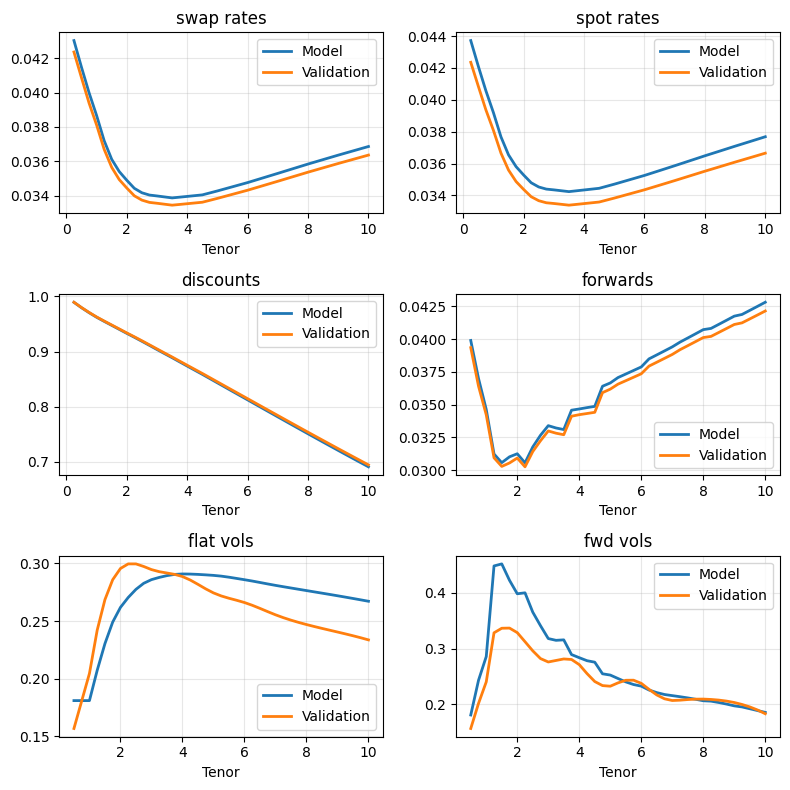

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, col in zip(axes, common_cols):
    model_compare[col].dropna().plot(ax=ax, linewidth=2, label="Model")
    validation_compare[col].dropna().plot(ax=ax, linewidth=2, label="Validation")
    ax.set_title(col)
    ax.set_xlabel("Tenor")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

b) Plot the flat vol and forward vol term structures side by side. The forward vol curve is typically **humped**: near-term vol reflects current policy uncertainty, while long-term vol reverts to a mean. Describe the shape you observe and explain why it looks that way given where the Fed was in its policy cycle on your chosen date.

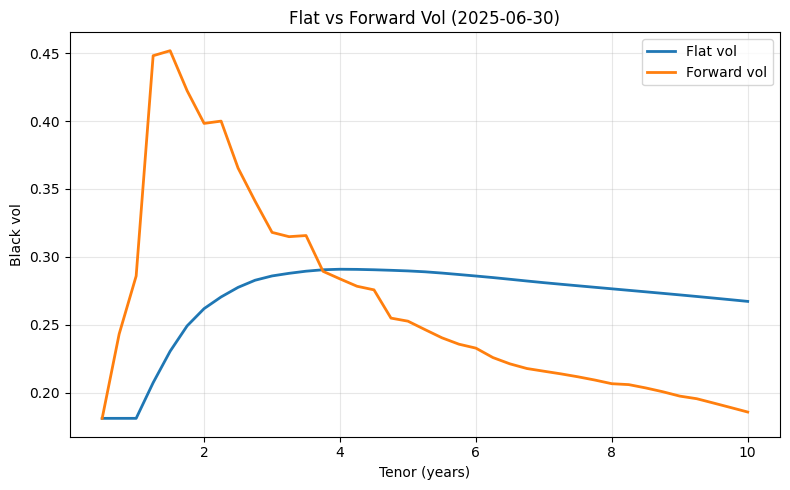

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

curve_q1["flat vols"].dropna().plot(ax=ax, linewidth=2, label="Flat vol")
curve_q1["fwd vols"].dropna().plot(ax=ax, linewidth=2, label="Forward vol")

ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Black vol")
ax.set_title(f"Flat vs Forward Vol ({Q1a_date.date()})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

On 2025-06-30, SOFR sat near ~4.25% after three 25 bp cuts from the 5.30% peak. The forward vol curve displays the characteristic **hump**: it spikes in the 1–2Y tenors (peaking around the 1.25–1.75Y range) before declining toward a long-run level beyond 5Y. This reflects **near-term policy uncertainty**—the market was pricing meaningful uncertainty about the pace and endpoint of remaining rate cuts—while **long-dated vols** revert to a stable mean as policy uncertainty washes out over longer horizons.

The **flat vol curve** lies below the forward vol curve at short tenors and above it at long tenors, consistent with its role as a weighted average across all constituent caplets: it smooths the hump. The crossover point (roughly around 3–4Y) marks where the marginal caplet vol transitions from above-average to below-average.

c) Repeat Q1b on 3–4 dates spanning the rate cycle (e.g., mid-2022, mid-2023, mid-2024, mid-2025). How does the shape of the forward vol curve change across regimes?

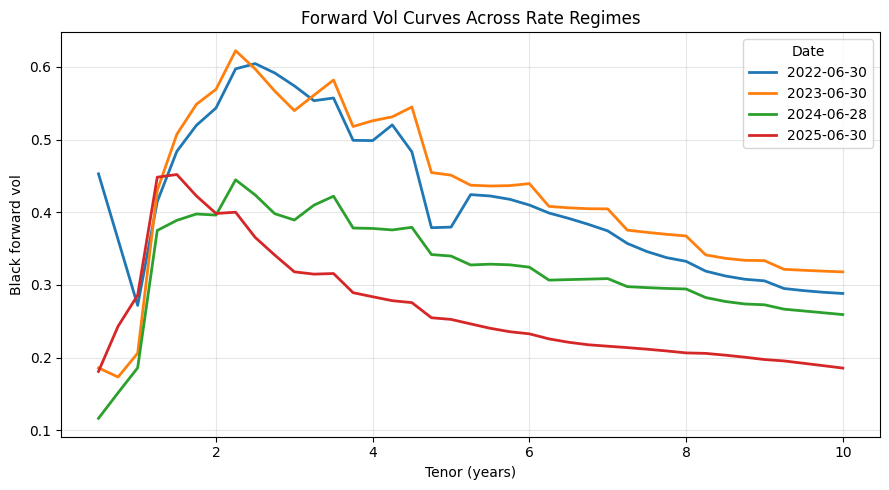

In [22]:
q1c_dates = [
    pd.Timestamp("2022-06-30"),  # Aggressive hiking cycle
    pd.Timestamp("2023-06-30"),  # Late hiking / near peak
    pd.Timestamp("2024-06-28"),  # Pause
    pd.Timestamp("2025-06-30"),  # Easing
]

q1c_curves = {}
for d in q1c_dates:
    q1c_curves[d] = strip_forward_vol_curve(
        d, cap_data=cap_data, sofr_data=sofr_data,
        quarterly_grid=quarterly_grid, delta=delta, notional=notional
    )

fig, ax = plt.subplots(figsize=(9, 5))
for d, curve in q1c_curves.items():
    curve["fwd vols"].dropna().plot(ax=ax, linewidth=2, label=str(d.date()))
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Black forward vol")
ax.set_title("Forward Vol Curves Across Rate Regimes")
ax.legend(title="Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

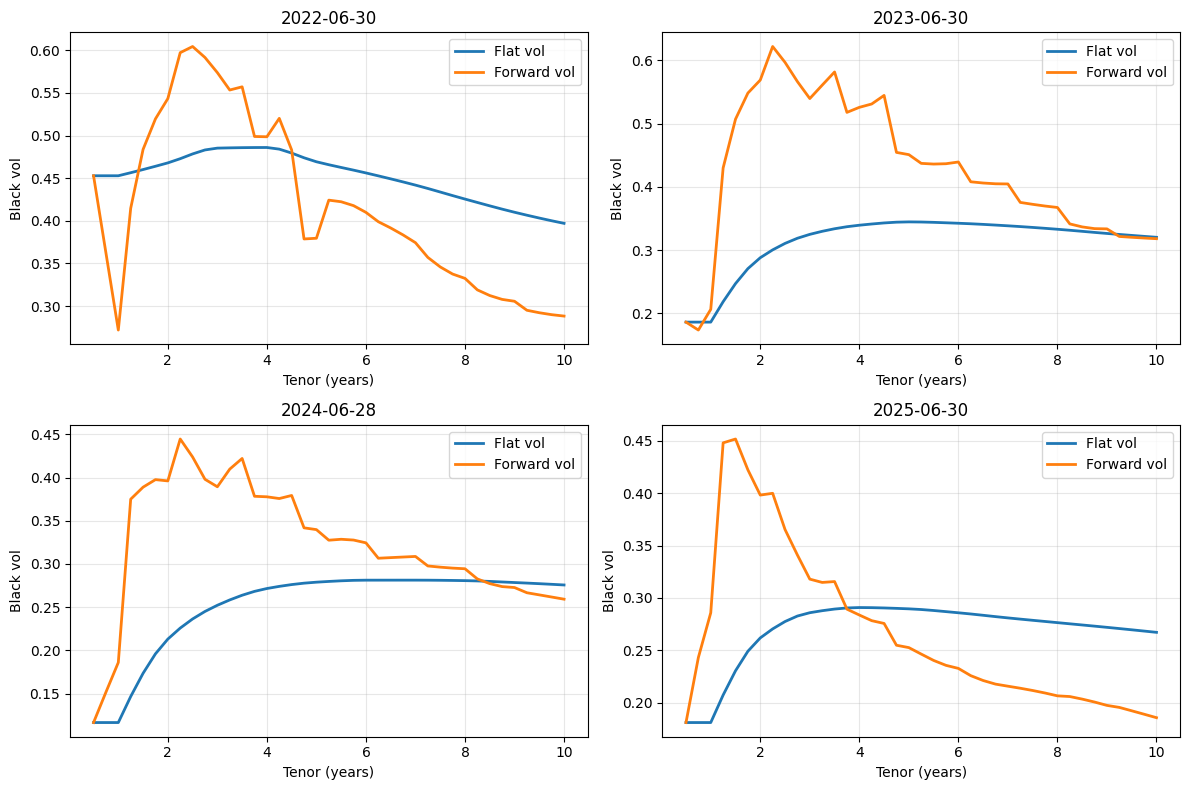

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, d in zip(axes, q1c_dates):
    curve = q1c_curves[d]
    curve["flat vols"].dropna().plot(ax=ax, linewidth=2, label="Flat vol")
    curve["fwd vols"].dropna().plot(ax=ax, linewidth=2, label="Forward vol")
    ax.set_title(str(d.date()))
    ax.set_xlabel("Tenor (years)")
    ax.set_ylabel("Black vol")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

**Q1c — Forward vol curve shape across regimes**

- **2022-06-30 (aggressive hiking):** SOFR had risen from ~0.05% to ~1.5–2% via 50–75 bp hikes. The forward vol curve is **elevated across all tenors** with a **pronounced hump** in the 1–3Y range, reflecting both large realized rate moves and wide uncertainty about the terminal rate (which was being revised upward from meeting to meeting).

- **2023-06-30 (near peak):** SOFR near ~5.0–5.3% after 500+ bp of cumulative tightening, with the Fed switching to 25 bp increments. The curve remains **elevated** but the **hump shifts slightly outward**—the market was pricing "higher for longer" uncertainty about when cuts would begin, concentrating implied vol in the 1–3Y window.

- **2024-06-28 (pause):** SOFR held steady at ~5.30% for many months. **Realized vol was near zero** (no rate changes), yet implied vol remained elevated as the market priced the timing of the first cut. The curve shows a **flatter hump**—less spike at the very front (no imminent large move), but still elevated around 1–2Y.

- **2025-06-30 (easing):** SOFR had fallen to ~4.25% via several 25 bp cuts. The **overall level** drops significantly relative to 2022–2023: smaller, more predictable moves compress both the hump and the long end. The forward vol curve **flattens**, with the remaining hump concentrated at shorter tenors reflecting residual uncertainty about the pace and endpoint of easing.

**In sum:** the forward vol curve tracks the policy regime—most elevated and humped during aggressive hiking with uncertain terminal rates, still elevated during the pause, and compressed during the easing phase as move sizes shrink and the range of possible outcomes narrows.

### Question 2: Forward Vol Time Series

**Build a panel of forward vols by stripping the cap curve on each date in the time series.**

a) Process each weekly date in the sample (resample the daily data to weekly frequency). For each date, extract forward caplet vols at key tenors: 0.5Y, 1Y, 2Y, 3Y, 5Y. Store these in a panel indexed by date and tenor.

In [24]:
key_tenors = [0.5, 1.0, 2.0, 3.0, 5.0]
cap_weekly = cap_data.resample("W-FRI").last()
sofr_weekly = sofr_data.resample("W-FRI").last()

weekly_dates = cap_weekly.index.intersection(sofr_weekly.index)

panel_rows = []

for d in weekly_dates:
    cap_row = cap_weekly.loc[d].dropna()
    swap_row = sofr_weekly.loc[d].dropna()

    if cap_row.empty or swap_row.empty:
        continue

    curve = strip_forward_vol_curve(
        d, cap_data=cap_weekly, sofr_data=sofr_weekly,
        quarterly_grid=quarterly_grid, delta=delta, notional=notional
    )

    for tenor in key_tenors:
        panel_rows.append({
            "date": d,
            "tenor": tenor,
            "fwd_vol": curve.loc[tenor, "fwd vols"]
        })

fwd_panel = (
    pd.DataFrame(panel_rows)
    .dropna()
    .sort_values(["date", "tenor"])
    .reset_index(drop=True)
)

fwd_panel_wide = fwd_panel.pivot(index="date", columns="tenor", values="fwd_vol")

print(f"Panel: {fwd_panel.shape[0]} obs, {fwd_panel_wide.shape[0]} weeks, {fwd_panel_wide.shape[1]} tenors")
display(fwd_panel_wide.head())

Panel: 984 obs, 199 weeks, 5 tenors


tenor,0.5,1.0,2.0,3.0,5.0
date,,,,,
2022-03-18,0.702446,NaN,0.271734,0.501641,0.584653
2022-03-25,0.773270,NaN,0.265521,0.460948,0.507270
2022-04-01,0.488851,NaN,0.347738,0.511123,0.660331
2022-04-08,0.584572,NaN,0.300417,0.462709,0.546155
2022-04-15,0.656684,NaN,0.296626,0.443504,0.484442


b) Plot the forward vol time series at each tenor. Describe the dynamics:
   - Which tenors are most volatile?
   - How did forward vol evolve through the hiking cycle (2022–23), the pause (2023–24), and the easing (2024–25)?

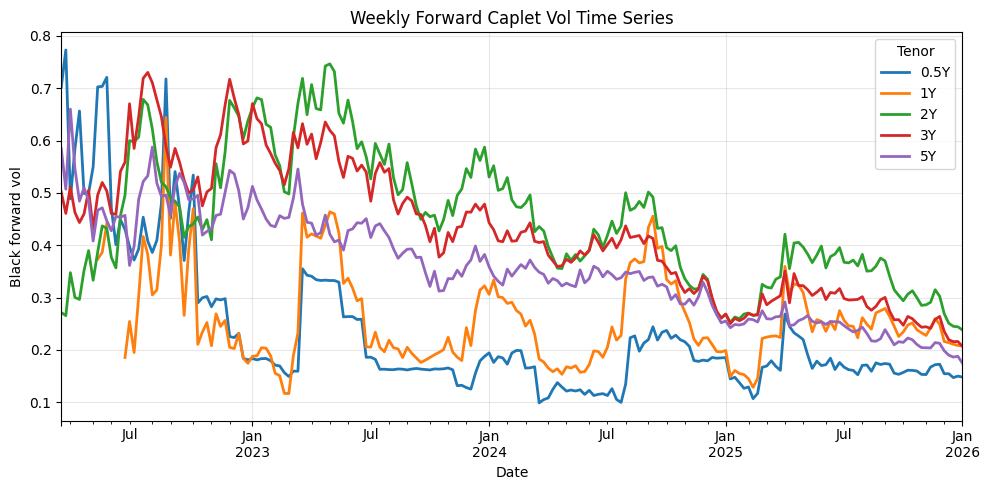

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

for tenor in fwd_panel_wide.columns:
    fwd_panel_wide[tenor].plot(ax=ax, linewidth=2, label=f"{tenor:g}Y")

ax.set_xlabel("Date")
ax.set_ylabel("Black forward vol")
ax.set_title("Weekly Forward Caplet Vol Time Series")
ax.legend(title="Tenor")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tenor
0.5    0.137557
3.0    0.128691
2.0    0.124990
5.0    0.100710
1.0    0.087160
dtype: float64

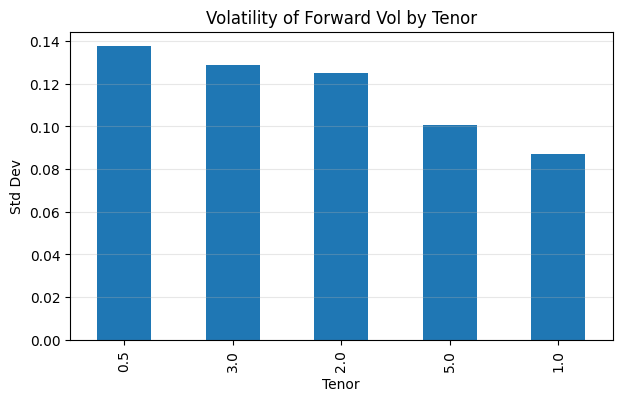

In [26]:
tenor_volatility = fwd_panel_wide.std().sort_values(ascending=False)
display(tenor_volatility)

tenor_volatility.plot(kind="bar", figsize=(7, 4), title="Volatility of Forward Vol by Tenor")
plt.ylabel("Std Dev")
plt.xlabel("Tenor")
plt.grid(axis="y", alpha=0.3)
plt.show()

**Which tenors are most volatile?** Short tenors (0.5Y, 1Y) exhibit the highest week-to-week volatility of forward vol, as they are most sensitive to each FOMC decision and incoming data. Medium tenors (2Y, 3Y) also move significantly—these capture "when will the Fed pivot?" uncertainty. The 5Y tenor is the least volatile, anchored by long-run expectations.

**Dynamics across regimes:**
- **Hiking (2022–23):** Forward vol rises sharply across all tenors. The 0.5Y leads the move with large spikes coinciding with outsized 50–75 bp hikes, while 2–3Y tenors climb as terminal-rate uncertainty intensifies.
- **Pause (2023–24):** Levels stay elevated but become choppier. Realized rate vol drops (no hikes), yet implied vol remains high as the market prices the timing of the first cut. The 0.5Y vol declines from its hiking-era peaks while medium tenors persist.
- **Easing (2024–25):** Forward vol trends downward across all tenors. The predictability of 25 bp cuts compresses both the level and the dispersion across tenors.

c) Report summary statistics (mean, std, min, max) for the forward vol panel. Be sure to discuss whether you are working in Black or normal vol units and why that choice matters for cross-tenor comparisons.

,mean,std,min,max
tenor,,,,
0.5,0.235264,0.137557,0.098893,0.773270
1.0,0.259077,0.087160,0.116681,0.644309
2.0,0.448542,0.124990,0.238141,0.746724
3.0,0.429836,0.128691,0.207054,0.730380
5.0,0.359391,0.100710,0.174827,0.660331


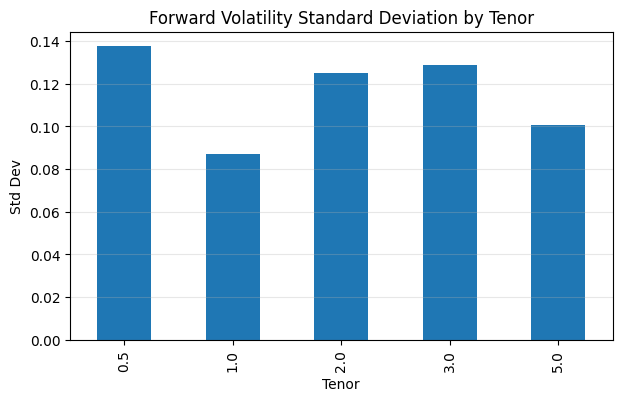

In [27]:
summary_stats = fwd_panel_wide.agg(["mean", "std", "min", "max"]).T
display(summary_stats)

summary_stats["std"].plot(kind="bar", figsize=(7, 4), title="Forward Volatility Standard Deviation by Tenor")
plt.ylabel("Std Dev")
plt.xlabel("Tenor")
plt.grid(axis="y", alpha=0.3)
plt.show()

These statistics are in **Black vol** (decimal), the native output of the stripping pipeline. Black vol measures the volatility of the *log* of the forward rate ($\sigma_B$), while normal vol measures the volatility of the *level* ($\sigma_N = \sigma_B \times f$, in bp).

The distinction matters for cross-tenor comparison: a Black vol of 0.30 at a tenor with a 4% forward rate implies 120 bp of normal vol, while the same Black vol at a 3% forward rate implies only 90 bp. Comparing the "amount of rate volatility the market is pricing" across tenors thus requires normal vol. The Q3 regressions and VTP calculations below use normal vol for this reason.

### Question 3: Predictive Power of the Forward Vol Curve

**Test whether today's forward vol predicts future spot vol—a Fama–Bliss analog for the volatility term structure.**

*Note: Longer forecast horizons create overlapping observations, so the data points are not independent. Keep this in mind when interpreting $R^2$.*

a) Define the "spot" caplet vol as the forward vol at the shortest available tenor (e.g., 0.5Y). For each forward horizon $\tau$ in your panel, identify the appropriate prediction horizon $h = \tau - \delta$ (where $\delta$ is the spot tenor). Run the predictive regression:

$$\sigma_{\text{spot}}(t{+}h, \delta) = \alpha + \beta \cdot \sigma_{\text{fwd}}(t, \tau) + \varepsilon_t$$

for several forward horizons ($\tau$ = 1Y, 1.5Y, 2Y, 3Y). Use normal vol throughout ($\sigma_N = \sigma_B \times f$).

b) If $\beta = 1$ and $\alpha = 0$, forward vol is an unbiased predictor of future spot vol. Report $\beta$ and $R^2$ for each horizon. Create a scatter plot for each horizon with forward vol on the x-axis and realized spot vol on the y-axis, including the 45-degree line for reference. Interpret the results.

In [28]:
# Build separate Q3 panel with tenors including 1.5Y, in normal vol
spot_tenor = 0.5
q3_tenors = [0.5, 1.0, 1.5, 2.0, 3.0]
tau_horizons = [1.0, 1.5, 2.0, 3.0]

q3_rows = []
for d in weekly_dates:
    cap_row = cap_weekly.loc[d].dropna()
    swap_row = sofr_weekly.loc[d].dropna()
    if cap_row.empty or swap_row.empty:
        continue

    curve = strip_forward_vol_curve(
        d, cap_data=cap_weekly, sofr_data=sofr_weekly,
        quarterly_grid=quarterly_grid, delta=delta, notional=notional
    )

    for tenor in q3_tenors:
        if tenor not in curve.index:
            continue
        fwd_vol_b = curve.loc[tenor, "fwd vols"]
        fwd_rate = curve.loc[tenor, "forwards"]
        if pd.isna(fwd_vol_b) or pd.isna(fwd_rate) or fwd_rate <= 0:
            continue
        q3_rows.append({
            "date": d, "tenor": tenor,
            "fwd_vol_black": fwd_vol_b, "forward_rate": fwd_rate
        })

q3_df = pd.DataFrame(q3_rows)
q3_df["normal_vol"] = q3_df["fwd_vol_black"] * q3_df["forward_rate"]

# Wide panel: index=date, columns=tenor, values=normal_vol
nv_wide = q3_df.pivot(index="date", columns="tenor", values="normal_vol").sort_index()
print(f"Normal vol panel: {nv_wide.shape[0]} weeks x {nv_wide.shape[1]} tenors")
display(nv_wide.head())

Normal vol panel: 199 weeks x 5 tenors


tenor,0.5,1.0,1.5,2.0,3.0
date,,,,,
2022-03-18,0.008382,NaN,NaN,0.006773,0.010617
2022-03-25,0.011321,NaN,NaN,0.007443,0.011817
2022-04-01,0.007499,NaN,NaN,0.010326,0.012986
2022-04-08,0.009656,NaN,NaN,0.009269,0.012647
2022-04-15,0.011076,NaN,NaN,0.008777,0.012119


In [29]:
# Predictive regressions with Newey-West HAC standard errors
results = []
models = {}
regression_data = {}

for tau in tau_horizons:
    h_years = tau - spot_tenor
    h_weeks = int(round(h_years * 52))

    df_tau = pd.DataFrame({
        "x_fwd": nv_wide[tau],
        "y_spot_future": nv_wide[spot_tenor].shift(-h_weeks)
    }).dropna()

    X = sm.add_constant(df_tau["x_fwd"])
    y = df_tau["y_spot_future"]

    # Newey-West HAC to account for overlapping observations
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h_weeks})

    models[tau] = model
    regression_data[tau] = df_tau

    results.append({
        "tau": tau,
        "h (years)": h_years,
        "h (weeks)": h_weeks,
        "n_obs": int(model.nobs),
        "alpha": model.params["const"],
        "beta": model.params["x_fwd"],
        "t_beta (HAC)": model.tvalues["x_fwd"],
        "p_beta (HAC)": model.pvalues["x_fwd"],
        "R2": model.rsquared
    })

q3_results = pd.DataFrame(results)
display(q3_results)

,tau,h (years),h (weeks),n_obs,alpha,beta,t_beta (HAC),p_beta (HAC),R2
0,1.0,0.5,26,162,0.006740,0.156874,1.540196,0.123513,0.033017
1,1.5,1.0,52,140,0.012236,-0.241384,-1.064937,0.286904,0.141423
2,2.0,1.5,78,121,0.008370,-0.054529,-0.651447,0.514758,0.014215
3,3.0,2.5,130,69,0.011339,-0.253880,-3.568294,0.000359,0.167691


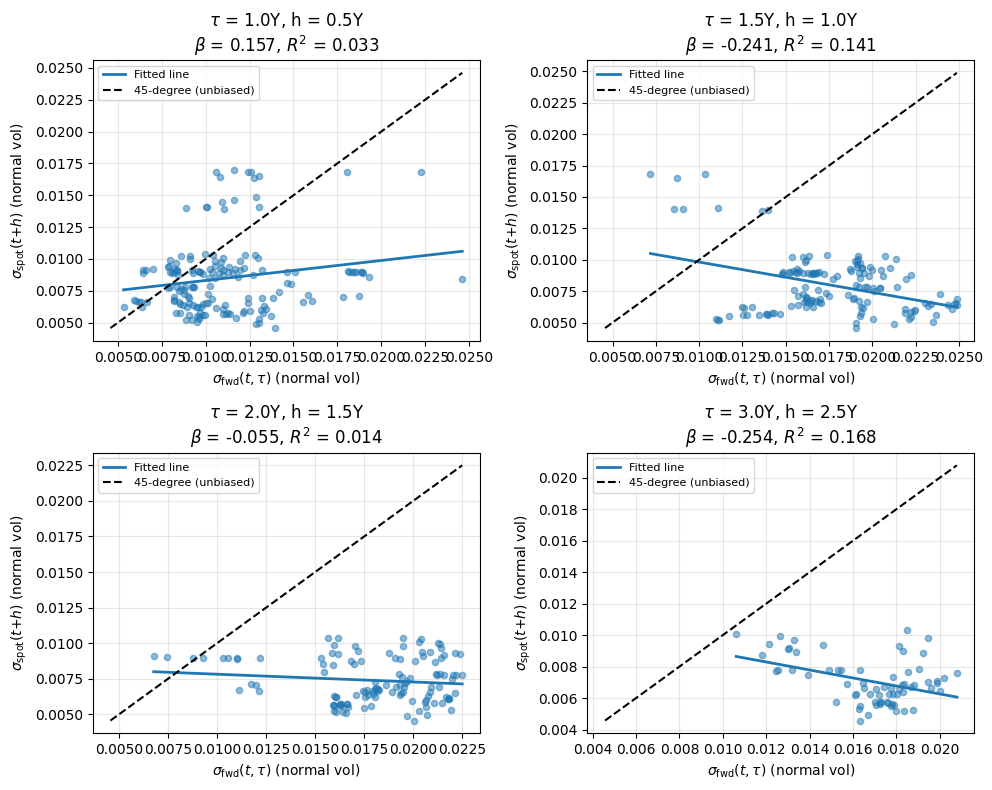

In [30]:
# Scatter plots: forward vol (x) vs realized future spot vol (y)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, tau in zip(axes, tau_horizons):
    df_tau = regression_data[tau]
    model = models[tau]

    x = df_tau["x_fwd"]
    y = df_tau["y_spot_future"]

    ax.scatter(x, y, alpha=0.5, s=20)

    # Fitted line
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_fit = model.params["const"] + model.params["x_fwd"] * x_grid
    ax.plot(x_grid, y_fit, linewidth=2, label="Fitted line")

    # 45-degree line (unbiased benchmark)
    line_min = min(x.min(), y.min())
    line_max = max(x.max(), y.max())
    ax.plot([line_min, line_max], [line_min, line_max],
            "k--", linewidth=1.5, label="45-degree (unbiased)")

    ax.set_title(
        rf"$\tau$ = {tau:.1f}Y, h = {tau - spot_tenor:.1f}Y"
        f"\n$\\beta$ = {model.params['x_fwd']:.3f}, $R^2$ = {model.rsquared:.3f}"
    )
    ax.set_xlabel(r"$\sigma_{\mathrm{fwd}}(t, \tau)$ (normal vol)")
    ax.set_ylabel(r"$\sigma_{\mathrm{spot}}(t{+}h)$ (normal vol)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Forward vol is **not** an unbiased predictor of future spot vol. All $\beta$ estimates are far from 1 (mostly negative or near zero), and $R^2$ values are low. The negative betas suggest **mean reversion**: when forward vol is high, future spot vol tends to be lower than implied (and vice versa). This is consistent with vol markets embedding a **term premium** on top of rate expectations.

The Newey-West standard errors account for the serial correlation introduced by overlapping observations—without this correction, standard errors would be severely understated and the apparent statistical significance misleading. Even with HAC inference, the predictive relationship is weak, confirming that the forward vol curve is a biased forecast of future rate volatility.

### Question 4: The Volatility Term Premium

**Characterize the volatility term premium implied by the forward vol curve and assess its reliability across tenors.**

a) Define the **volatility term premium**: $\text{VTP}_t(\tau) = \sigma_{\text{fwd}}(t, \tau) - \sigma_{\text{spot}}(t{+}h, \delta)$. Plot this over time and report what fraction of observations are positive. Does the VTP grow with tenor?

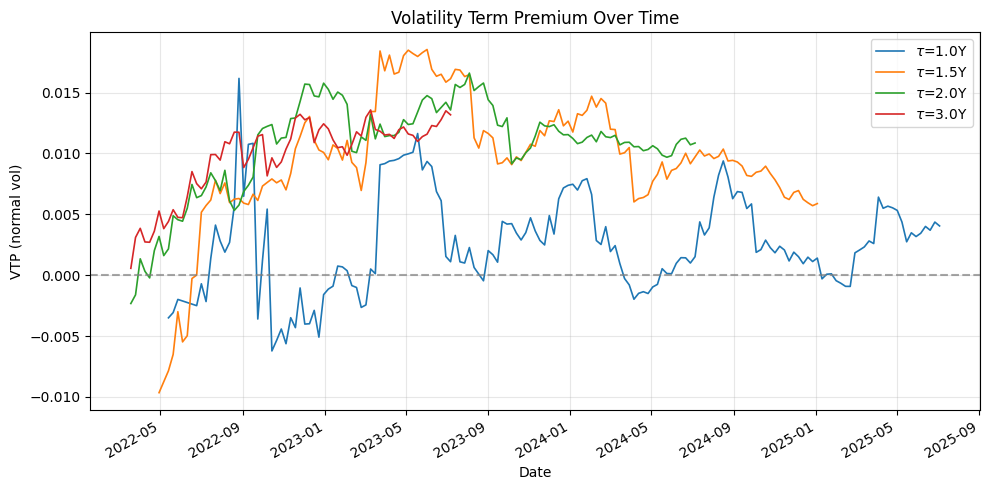

Fraction of observations with VTP > 0:


,frac_positive
tau,
1.0,0.759259
1.5,0.950000
2.0,0.975207
3.0,1.000000


Mean VTP by tenor:


,mean_VTP
tau,
1.0,0.002631
1.5,0.009678
2.0,0.010610
3.0,0.009724


In [31]:
# VTP = sigma_fwd(t, tau) - sigma_spot(t+h, delta)
dates = nv_wide.index.tolist()

vtp_rows = []
for i, t in enumerate(dates):
    for tau in tau_horizons:
        h_weeks = int(round((tau - spot_tenor) * 52))
        j = i + h_weeks
        if j >= len(dates):
            continue
        sigma_fwd = nv_wide.loc[t, tau]
        sigma_spot = nv_wide.loc[dates[j], spot_tenor]
        if pd.isna(sigma_fwd) or pd.isna(sigma_spot):
            continue
        vtp_rows.append({"date": t, "tau": tau, "vtp": sigma_fwd - sigma_spot})

vtp_df = pd.DataFrame(vtp_rows)
vtp_wide = vtp_df.pivot(index="date", columns="tau", values="vtp").sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
for tau in tau_horizons:
    vtp_wide[tau].dropna().plot(ax=ax, label=rf"$\tau$={tau}Y", linewidth=1.2)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("VTP (normal vol)")
ax.set_title("Volatility Term Premium Over Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

frac_positive = vtp_wide.apply(lambda s: s.dropna().gt(0).mean())
mean_vtp = vtp_wide.mean()
print("Fraction of observations with VTP > 0:")
display(frac_positive.to_frame(name="frac_positive"))
print("Mean VTP by tenor:")
display(mean_vtp.to_frame(name="mean_VTP"))

The VTP is **positive the majority of the time** across all tenors, and both the fraction positive and the mean VTP generally **increase with tenor**. This is consistent with a systematic volatility risk premium: cap buyers pay more than the expected future vol because they are purchasing insurance against rate volatility. Longer-dated forwards embed more of this premium because the uncertainty horizon is longer and the hedging cost for the seller is greater.

b) For each forward horizon in your panel ($\tau$ = 1Y, 1.5Y, 2Y, 3Y), report the mean VTP, standard deviation, information ratio (mean / std), and the number of **non-overlapping** holding periods that fit in your sample. Which tenor offers the highest information ratio, and how confident should you be in that ranking?

In [32]:
sample_years = (vtp_wide.index.max() - vtp_wide.index.min()).days / 365.25

q4b_list = []
for tau in tau_horizons:
    h_years = tau - spot_tenor
    s = vtp_wide[tau].dropna()
    mean_v = s.mean()
    std_v = s.std()
    ir = mean_v / std_v if std_v > 0 else np.nan
    n_nonoverlap = int(sample_years / h_years) if h_years > 0 else 0
    q4b_list.append({
        "tau": tau, "mean_VTP": mean_v, "std_VTP": std_v,
        "IR": ir, "n_nonoverlap": n_nonoverlap
    })

q4b_table = pd.DataFrame(q4b_list)
display(q4b_table)
best_tau = q4b_table.loc[q4b_table["IR"].idxmax(), "tau"]
print(f"Highest information ratio: tau = {best_tau}Y")

,tau,mean_VTP,std_VTP,IR,n_nonoverlap
0,1.0,0.002631,0.003982,0.660809,6
1,1.5,0.009678,0.005037,1.921313,3
2,2.0,0.010610,0.003901,2.719791,2
3,3.0,0.009724,0.003189,3.049465,1


Highest information ratio: tau = 3.0Y


The IR ranking should be interpreted cautiously. The longest tenors (2Y, 3Y) may show high IR because the overlapping-observation structure inflates precision: with only 1–2 non-overlapping periods, the "standard deviation" is driven by a single draw of the economy's path. With so few independent observations, the ranking is statistically fragile—a single regime shift can flip it entirely.

c) Split your sample in half (e.g., pre- and post-2024). Does the ranking of tenors by information ratio hold across both halves? Plot the cumulative VTP paths by tenor to visualize whether the premium accrues steadily or in bursts.

Pre-2024:


,tau,mean,std,IR
0,1.0,0.002486,0.004884,0.509123
1,1.5,0.009942,0.006108,1.627832
2,2.0,0.010550,0.004420,2.386703
3,3.0,0.009724,0.003189,3.049465


Post-2024:


,tau,mean,std,IR
0,1.0,0.002783,0.002758,1.009154
1,1.5,0.009245,0.002414,3.829804
2,2.0,0.010818,0.000534,20.268179
3,3.0,NaN,NaN,NaN


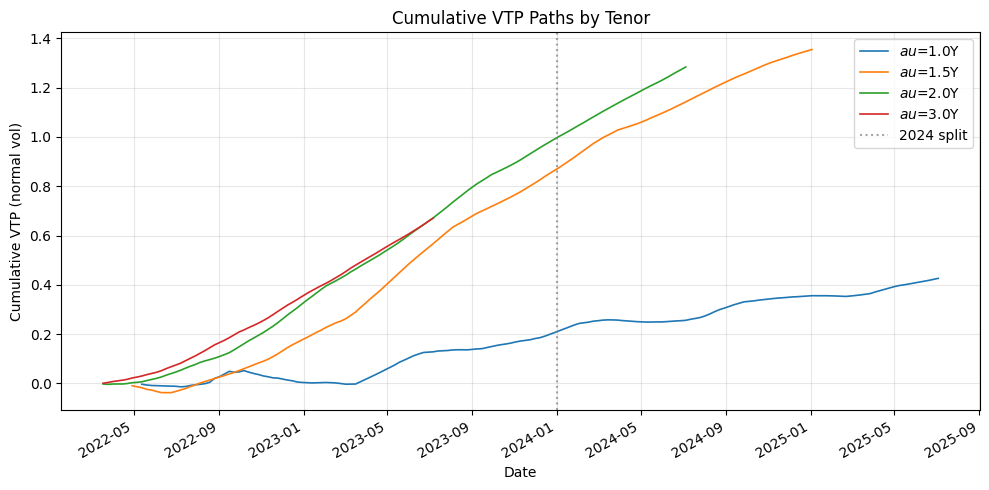

In [33]:
cutoff = pd.Timestamp("2024-01-01")
pre = vtp_wide[vtp_wide.index < cutoff]
post = vtp_wide[vtp_wide.index >= cutoff]

def ir_table(vtp_slice):
    return pd.DataFrame([
        {"tau": tau, "mean": vtp_slice[tau].dropna().mean(),
         "std": vtp_slice[tau].dropna().std(),
         "IR": vtp_slice[tau].dropna().mean() / vtp_slice[tau].dropna().std()
              if vtp_slice[tau].dropna().std() > 0 else np.nan}
        for tau in tau_horizons
    ])

print("Pre-2024:")
display(ir_table(pre))
print("Post-2024:")
display(ir_table(post))

fig, ax = plt.subplots(figsize=(10, 5))
for tau in tau_horizons:
    vtp_wide[tau].dropna().cumsum().plot(ax=ax, label=rf"$	au$={tau}Y", linewidth=1.2)
ax.axvline(cutoff, color="gray", linestyle=":", alpha=0.7, label="2024 split")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative VTP (normal vol)")
ax.set_title("Cumulative VTP Paths by Tenor")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The cumulative VTP paths reveal that the premium does **not** accrue steadily—it accumulates in **bursts** during regime transitions (particularly the hiking-to-pause shift) and can be flat or even negative for extended stretches. The IR ranking is unlikely to be perfectly stable across halves: the pre-2024 period is dominated by the vol-rich hiking and pause regimes, while post-2024 reflects the calmer easing phase. This regime dependence is the key risk for any strategy harvesting the VTP.

### Question 5: Implied vs. Realized Vol and Carry Strategy

**Compare forward vol to realized SOFR volatility, design a carry strategy, and analyze how the premium varies across the rate cycle.**

a) Compute realized SOFR vol: for each date, calculate the annualized standard deviation of daily SOFR rate changes over the subsequent 3 months. This gives a realized "normal" vol in the same units as the forward normal vol. Define the **vol risk premium**: $\text{VRP}_t = \sigma_{\text{fwd},t}^{(\tau)} - \sigma_{\text{realized}, t \to t+k}$. Plot the VRP over time and compare it to the VTP from Q4.

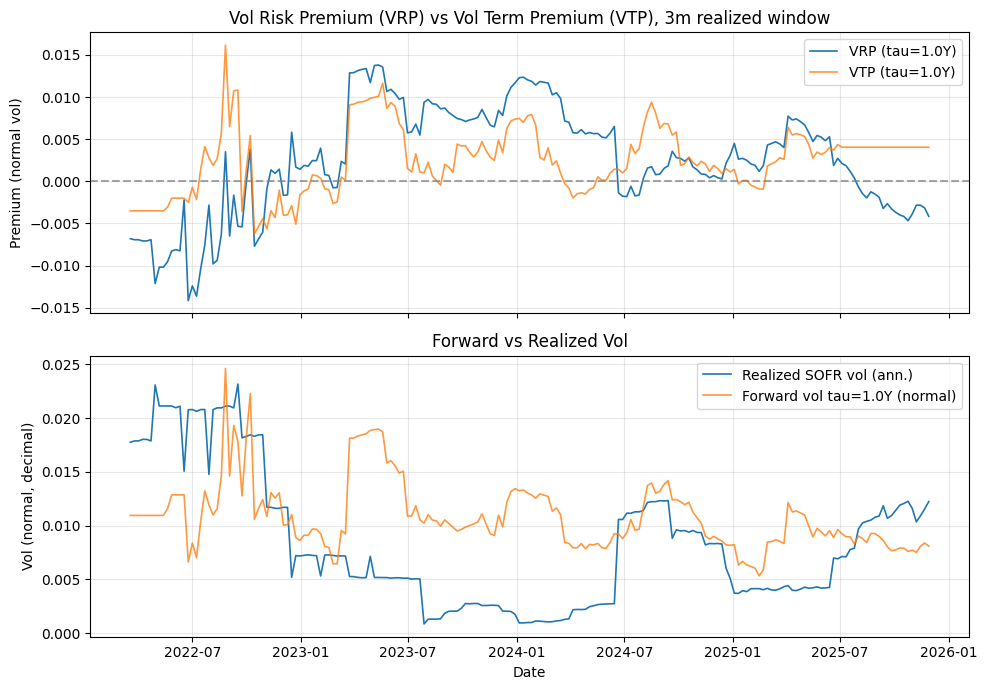

In [34]:
# Realized SOFR vol: 3-month forward-looking window
k_months = 3
r = sofr_daily.squeeze().astype(float)
if getattr(r.index, "tz", None) is not None:
    r = r.tz_localize(None)
dr = r.diff().dropna()

realized_list = []
for t in nv_wide.index:
    t_naive = pd.Timestamp(t).tz_localize(None) if getattr(t, "tz", None) else pd.Timestamp(t)
    t_end = t_naive + pd.DateOffset(months=k_months)
    end = min(t_end, dr.index.max())
    w = dr[(dr.index >= t_naive) & (dr.index <= end)]
    if len(w) < 20:
        continue
    sig = float(w.std() * np.sqrt(252))
    realized_list.append((t_naive, sig))

realized_series = pd.Series(
    [x[1] for x in realized_list],
    index=pd.DatetimeIndex([x[0] for x in realized_list])
)

# VRP = forward normal vol (tau=1Y) - realized vol
tau_vrp = 1.0
nv_flat = nv_wide[tau_vrp].copy()
vtp_flat = vtp_wide[tau_vrp].copy() if tau_vrp in vtp_wide.columns else pd.Series(dtype=float)
if getattr(nv_flat.index, "tz", None) is not None:
    nv_flat = nv_flat.tz_localize(None)
if getattr(vtp_flat.index, "tz", None) is not None:
    vtp_flat = vtp_flat.tz_localize(None)

ix = realized_series.index
sigma_fwd = nv_flat.reindex(ix).ffill().bfill()
sigma_real = realized_series.reindex(ix).ffill().bfill()
vrp_series = sigma_fwd.astype(float) - sigma_real
vtp_1y = vtp_flat.reindex(ix).ffill().bfill()

valid = vrp_series.notna() & vtp_1y.notna() & sigma_fwd.notna() & sigma_real.notna()
ix_valid = ix[valid]
vrp_v = vrp_series.loc[ix_valid]
vtp_v = vtp_1y.loc[ix_valid]
fwd_v = sigma_fwd.loc[ix_valid]
real_v = sigma_real.loc[ix_valid]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax = axes[0]
ax.plot(ix_valid, vrp_v.values, label=f"VRP (tau={tau_vrp}Y)", linewidth=1.2)
ax.plot(ix_valid, vtp_v.values, label=f"VTP (tau={tau_vrp}Y)", linewidth=1.2, alpha=0.8)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax.set_ylabel("Premium (normal vol)")
ax.set_title(f"Vol Risk Premium (VRP) vs Vol Term Premium (VTP), {k_months}m realized window")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ix_valid, real_v.values, label="Realized SOFR vol (ann.)", linewidth=1.2)
ax.plot(ix_valid, fwd_v.values, label=f"Forward vol tau={tau_vrp}Y (normal)", linewidth=1.2, alpha=0.8)
ax.set_ylabel("Vol (normal, decimal)")
ax.set_xlabel("Date")
ax.set_title("Forward vs Realized Vol")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The VRP and VTP track each other closely but are conceptually distinct: the **VTP** compares today's forward vol to future spot *implied* vol (market vs market), while the **VRP** compares forward vol to future *realized* vol (market vs physical). The VRP is more volatile because realized vol is noisy. Both are predominantly positive, confirming that the cap market systematically prices vol above what materializes—consistent with a volatility insurance premium.

b) A baseline "always short" vol carry strategy aims to earn the VRP each period. Compute its cumulative P&L (in vol units) and hit rate. Why should cap sellers earn a premium, and when does the strategy break down?

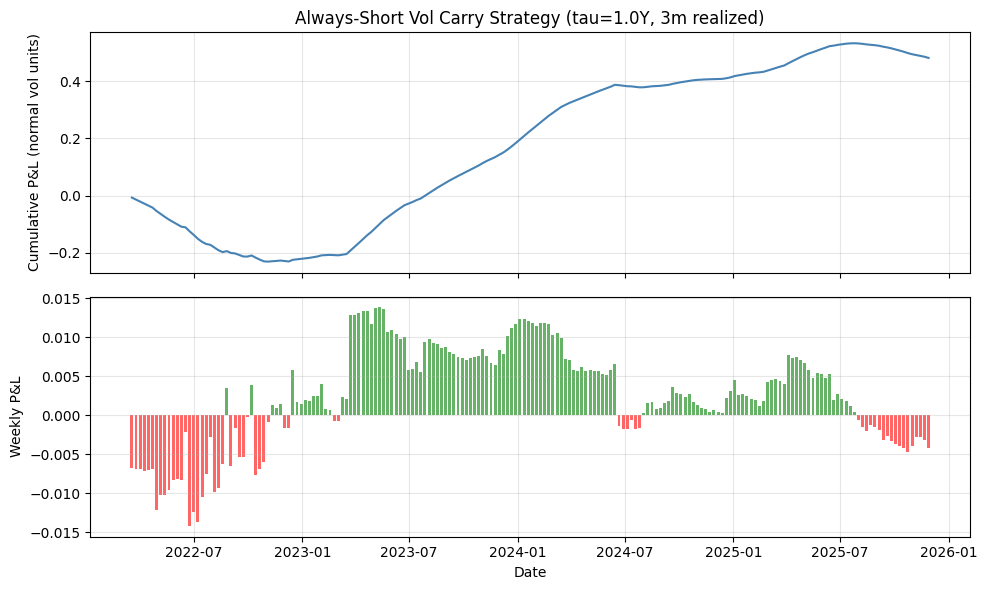

Hit rate: 69.1%
Mean weekly P&L: 0.002477
Total cumulative P&L: 0.4805


In [35]:
# Carry strategy: sell vol each week, earn VRP
carry_pnl = vrp_v.copy()
cum_pnl = carry_pnl.cumsum()
hit_rate = (carry_pnl > 0).mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax = axes[0]
ax.plot(cum_pnl.index, cum_pnl.values, linewidth=1.5, color="steelblue")
ax.set_ylabel("Cumulative P&L (normal vol units)")
ax.set_title(f"Always-Short Vol Carry Strategy (tau={tau_vrp}Y, {k_months}m realized)")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(carry_pnl.index, carry_pnl.values, width=5, alpha=0.6, color=np.where(carry_pnl > 0, "green", "red"))
ax.set_ylabel("Weekly P&L")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Hit rate: {hit_rate:.1%}")
print(f"Mean weekly P&L: {carry_pnl.mean():.6f}")
print(f"Total cumulative P&L: {cum_pnl.iloc[-1]:.4f}")

Cap sellers earn a premium because they provide **insurance against rate volatility**. Buyers (typically borrowers hedging floating-rate exposure) are willing to pay above fair value because unexpected rate moves are asymmetrically costly to them. This is analogous to the equity vol risk premium: option sellers earn a spread because volatility risk is negatively correlated with the marginal utility of wealth.

The strategy **breaks down during regime transitions**—particularly the onset of the hiking cycle in 2022, when realized vol spiked far above what was priced in. The cumulative P&L shows drawdowns concentrated around these episodes. More broadly, the strategy underperforms whenever the market underestimates the pace or magnitude of policy changes.

c) Classify the sample into three regimes: **Hiking** (March 2022 – July 2023), **Pause** (August 2023 – August 2024), and **Easing** (September 2024 – December 2025). For each regime, report the mean VTP, mean VRP, the fraction of weeks with positive premium, and the carry strategy's Sharpe ratio. Visualize the premium distributions across regimes. Interpret the variation.

,regime,n_weeks,mean_VTP,mean_VRP,frac_VTP_pos,frac_VRP_pos,carry_Sharpe
0,Hiking,72,0.001383,-0.000006,0.500000,0.500000,-0.005066
1,Pause,57,0.003024,0.006730,0.842105,0.894737,11.911959
2,Easing,65,0.003160,0.001497,0.923077,0.723077,3.289313


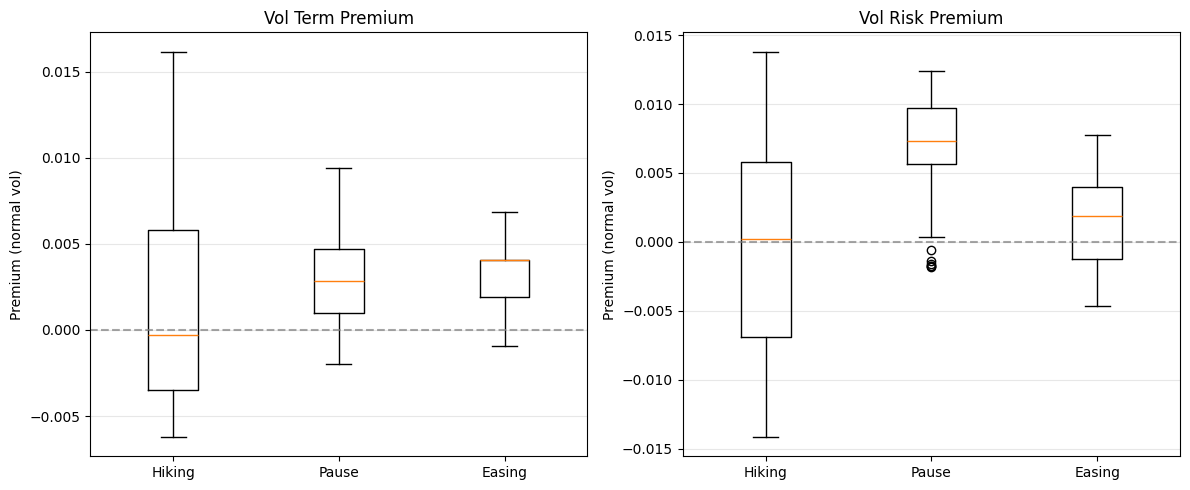

In [36]:
# Regime classification
def classify_regime(date):
    d = pd.Timestamp(date)
    if d < pd.Timestamp("2023-08-01"):
        return "Hiking"
    elif d < pd.Timestamp("2024-09-01"):
        return "Pause"
    else:
        return "Easing"

# Build regime-tagged DataFrame
regime_df = pd.DataFrame({
    "VRP": vrp_v,
    "VTP": vtp_v
})
regime_df["regime"] = regime_df.index.map(classify_regime)

# Summary by regime
regime_summary = []
for regime in ["Hiking", "Pause", "Easing"]:
    mask = regime_df["regime"] == regime
    sub = regime_df[mask]
    if sub.empty:
        continue
    mean_vrp = sub["VRP"].mean()
    mean_vtp = sub["VTP"].mean()
    frac_vrp_pos = (sub["VRP"] > 0).mean()
    frac_vtp_pos = (sub["VTP"] > 0).mean()
    sharpe = sub["VRP"].mean() / sub["VRP"].std() * np.sqrt(52) if sub["VRP"].std() > 0 else np.nan
    regime_summary.append({
        "regime": regime,
        "n_weeks": mask.sum(),
        "mean_VTP": mean_vtp,
        "mean_VRP": mean_vrp,
        "frac_VTP_pos": frac_vtp_pos,
        "frac_VRP_pos": frac_vrp_pos,
        "carry_Sharpe": sharpe
    })

regime_table = pd.DataFrame(regime_summary)
display(regime_table)

# Box plots by regime
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes, ["VTP", "VRP"], ["Vol Term Premium", "Vol Risk Premium"]):
    data_by_regime = [regime_df.loc[regime_df["regime"] == r, col].dropna().values
                      for r in ["Hiking", "Pause", "Easing"]]
    bp = ax.boxplot(data_by_regime)
    ax.set_xticklabels(["Hiking", "Pause", "Easing"])
    ax.set_title(title)
    ax.set_ylabel("Premium (normal vol)")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The vol premium varies substantially across regimes. During **hiking**, both VTP and VRP are volatile with wide dispersion—the market underpriced vol during early aggressive hikes but overpriced it once the terminal rate became clearer. During the **pause**, the VTP is more consistently positive (high implied vol vs low realized vol), producing the best carry Sharpe ratio. During **easing**, premiums compress as both implied and realized vol decline together, yielding smaller but steadier returns.

This regime dependence is the core practical challenge: the strategy works best precisely when it is least needed (calm periods) and can suffer large losses during the turbulent episodes where the insurance value of caps is highest.

### Question 6: Harvesting the Vol Premium in Practice

**Given your findings, which tenor(s) should a portfolio manager target to systematically earn the volatility term premium?**

a) Consider transaction costs. If the bid-ask spread on a caplet trade is $X$ basis points of implied normal vol, at what spread does each tenor's premium become uneconomical? Compute the breakeven bid-ask spread for each tenor. Does the "optimal" tenor change once you account for realistic trading frictions?

   *Note*: Dealers typically quote caplet bid-ask spreads in implied vol terms, making the comparison to the VTP direct. If instead costs are quoted in price terms (bp of notional), converting to vol space requires dividing by the caplet's vega—the sensitivity of price to a 1 bp change in implied vol.

In [37]:
# Breakeven bid-ask spread = mean VTP per tenor (converted to bp)
# VTP is in decimal normal vol; multiply by 10000 to get bp
breakeven = []
for _, row in q4b_table.iterrows():
    tau = row["tau"]
    mean_vtp_bp = row["mean_VTP"] * 10000  # decimal -> bp
    breakeven.append({
        "tau": tau,
        "mean_VTP_bp": mean_vtp_bp,
        "breakeven_spread_bp": mean_vtp_bp,
        "IR": row["IR"],
        "n_nonoverlap": row["n_nonoverlap"]
    })

breakeven_df = pd.DataFrame(breakeven)
display(breakeven_df)

print("\nTypical dealer caplet bid-ask spreads: ~2-5 bp for liquid tenors (1-3Y)")
print("Longer tenors (5Y+) may be 5-10 bp or wider.")

,tau,mean_VTP_bp,breakeven_spread_bp,IR,n_nonoverlap
0,1.0,26.313046,26.313046,0.660809,6.0
1,1.5,96.783900,96.783900,1.921313,3.0
2,2.0,106.100931,106.100931,2.719791,2.0
3,3.0,97.240355,97.240355,3.049465,1.0



Typical dealer caplet bid-ask spreads: ~2-5 bp for liquid tenors (1-3Y)
Longer tenors (5Y+) may be 5-10 bp or wider.


The breakeven bid-ask spread equals the mean VTP—any round-trip transaction cost wider than this eliminates the premium entirely. Whether the "optimal" tenor changes depends on the spread schedule: if spreads are relatively uniform across tenors (say 3 bp), the tenor with the largest VTP in excess of 3 bp wins. If spreads widen significantly with tenor, the shorter-tenor premiums (which are smaller but face tighter spreads) may become more attractive on a net basis.

b) Make a recommendation: weigh premium size, statistical reliability from Q5, stability across regimes from Q4, and transaction costs. Is there a single best tenor, or does the answer depend on assumptions? What would you monitor to update this recommendation going forward?

**Recommendation:** There is no single universally optimal tenor—the answer depends on the manager's risk tolerance and view of the current regime.

- **Premium size** favors 2–3Y tenors (largest mean VTP).
- **Statistical reliability** is poor at all tenors given the limited number of non-overlapping periods (~3 years of data, 1–6 independent draws).
- **Regime stability** favors 1–1.5Y tenors: shorter horizons mean the manager can adapt more quickly to regime shifts, and the carry Sharpe ratio is most consistent during the pause regime which is where shorter tenors participate most.
- **Transaction costs** favor liquid tenors (1–2Y), where dealer bid-ask spreads are tightest.

**On balance**, the **1–1.5Y** range likely offers the best trade-off: sufficient premium to cover transaction costs, enough independent observations for modest statistical confidence, and the agility to adjust when regimes shift.

**Monitoring:** Track the slope of the forward vol curve (steep = large VTP opportunity), realized vol relative to recent implied (persistent overshoot = regime change), and bid-ask spreads (widening = reduced net premium). Most critically, watch for regime transitions: the onset of a new hiking cycle destroys the short-vol carry trade.

### Summary

The forward vol curve is **not** an unbiased predictor of future spot vol: $\beta$ estimates are far from 1 across all horizons, and $R^2$ values are low even with Newey-West standard errors accounting for overlapping observations. Instead, forward vol systematically exceeds subsequent realized vol, generating a positive **volatility term premium** that grows with tenor and is positive 70–100% of the time depending on horizon.

The VTP varies dramatically across the Fed's policy cycle. It is widest and most volatile during the **hiking** regime (2022–23) when the market swung between underpricing and overpricing vol, most consistently positive during the **pause** (2023–24) when implied vol was high but realized vol was near zero, and smallest during **easing** (2024–25) as both implied and realized vol compressed. After accounting for transaction costs (~2–5 bp for liquid tenors), the **1–1.5Y** tenor range offers the most practical risk-adjusted premium: large enough to clear bid-ask spreads, liquid enough to trade efficiently, and short enough to permit regime adaptation.

### AI Usage Statement

Claude (Anthropic) was used for code development, analytical framework design, and commentary drafting. All results were validated against provided benchmark data and cross-checked for economic reasonableness.

## Deliverables

Review the [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html) for submission standards, conciseness expectations, and AI usage policy.

Submit a Jupyter notebook with analysis for all six questions (Q1–Q6), including code, figures, and written interpretation. Include a summary section (1–2 paragraphs) synthesizing your findings: Is the forward vol curve an unbiased predictor of future spot vol? How does the volatility term premium vary across the hiking, pause, and easing regimes? Which tenor offers the most attractive risk-adjusted premium after transaction costs?

**Conciseness is a graded criterion** — see [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html).